In [4]:
# %pip install -e .
# %pip install -r requirements.txt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
from dataprofile import dataprofile
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Quick test of the direct-search

In [ ]:


# tester aussi le c, la seed, et 
# sans le warmstart, pas de tableau clair, même l'intrinsèque semble meilleur.
# Problème: le problème n'est pas convexe. Peut-être que la métrique pour les dataprofiles devrait être la norme du gradient

vd = [5]
n = 2
noise = 0 #1e-6 
vseed = [45]
warmstart = 0 #0.2 #0.2 #10000*noise

simplexbudget = 200
projections = [0,1]
psstypes = [1,2,3]
rotations = [1]
euclsimplexs = [1]
gamma = 0.5
Gamma = 2
alpha_0 = 1.0
alpha_max = 1.0
c = 0.01 # si c trop petit, favorable au intrinsèques ?

# c trop petit : projeté meilleur
# warmstart : pas important pour 
# seed
# noise ?


cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]
VF = []
for d in vd:
    plt.figure(figsize=(10, 6))
    plt.show()
    for seed in vseed:
        problem = ProblemSynchRotations(d=d,n=n,noise = noise, seed=seed,warmstart = warmstart)
        point = problem.xstar
        H = problem.H
        H_new = point[0].dot(point[1].T)
        print("DIIIIFFFF",H_new-H)
        for psstype, projection, rotation, euclsimplex in itertools.product(psstypes, projections, rotations, euclsimplexs):
            print(f"Running with psstype={psstype}, projection={projection}, rotation={rotation}, budget={simplexbudget}, simplextype={euclsimplex}")
            result_ds = directsearch(
                    problem,
                    simplexbudget = simplexbudget,
                    projection = projection,
                    psstype = psstype,
                    rotation = rotation,
                    euclsimplex = euclsimplex,
                    gamma = gamma,
                    Gamma = Gamma,
                    alpha_0 = alpha_0,
                    alpha_max = alpha_max,
                    c = c)
            res = result_ds
            vf = res["vf"]
            vx = np.cumsum(res["per_iteration_evaluations"])
            cvg = res["stopcriterion"]
            print(f"Convergence criterion: {cvg}")
            # print(vx)
            plt.plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )
            VF.append(vf[-1])
            print("hey")
    plt.grid()
    plt.title(f"d={d} - budget={simplexbudget}")

    plt.xlabel("Number of evaluations")
    plt.legend()
    print(VF)

<Figure size 1000x600 with 0 Axes>

DIIIIFFFF [[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]
Running with psstype=1, projection=0, rotation=1, budget=200, simplextype=1
Convergence criterion: full budget used
hey
Running with psstype=1, projection=1, rotation=1, budget=200, simplextype=1
Convergence criterion: full budget used
hey
Running with psstype=2, projection=0, rotation=1, budget=200, simplextype=1
Convergence criterion: full budget used
hey
Running with psstype=2, projection=1, rotation=1, budget=200, simplextype=1


In [4]:
import os
import pickle
path_frame = "experiments/2026-04-28_2rotations_k5_v1/results/results_2026-04-28_14-47-27.pkl"
with open(path_frame, "rb") as f:
    df = pickle.load(f)

# display(results["result"].iloc[0])
# display(df)
display(df.columns)
df = df.drop(['idpb', 'alpha_0', 'gamma', 'Gamma','alpha_max','idalgo'], axis=1)

display(df.columns)


# TODO: compute riemannian and euclidean duration

# display(df["rb_valpha"].iloc[0])
display(df["simplexbudget"].unique())


# Now creating the data profile

a  = len(df["seed"].unique())
c = df.copy()
print(c.columns)

df['rb_lastf'] = df['rb_vf'].transform(lambda x: x[-1] if len(x) > 0 else None)
display(df["rb_vf"])
display(df["psstype"].unique())




Index(['seed', 'n', 'd', 'noise', 'warmstart', 'idpb', 'psstype', 'projection',
       'rotation', 'simplexbudget', 'euclsimplex', 'gamma', 'Gamma', 'alpha_0',
       'alpha_max', 'c', 'idalgo', 'euclideansimplex', 'vf',
       'per_iteration_evaluations', 'valpha', 'stopcriterion', 'last_iterate',
       'rb_vf', 'rb_per_iteration_evaluations', 'rb_valpha',
       'rb_stopcriterion', 'rb_last_iterate', 'duration', 'problem'],
      dtype='object')

Index(['seed', 'n', 'd', 'noise', 'warmstart', 'psstype', 'projection',
       'rotation', 'simplexbudget', 'euclsimplex', 'c', 'euclideansimplex',
       'vf', 'per_iteration_evaluations', 'valpha', 'stopcriterion',
       'last_iterate', 'rb_vf', 'rb_per_iteration_evaluations', 'rb_valpha',
       'rb_stopcriterion', 'rb_last_iterate', 'duration', 'problem'],
      dtype='object')

array([500])

Index(['seed', 'n', 'd', 'noise', 'warmstart', 'psstype', 'projection',
       'rotation', 'simplexbudget', 'euclsimplex', 'c', 'euclideansimplex',
       'vf', 'per_iteration_evaluations', 'valpha', 'stopcriterion',
       'last_iterate', 'rb_vf', 'rb_per_iteration_evaluations', 'rb_valpha',
       'rb_stopcriterion', 'rb_last_iterate', 'duration', 'problem'],
      dtype='object')


0       [10.827778638593324, 9.802124818626599, 8.4625...
1       [10.827778638593324, 8.055722825683823, 6.9038...
2       [10.827778638593324, 9.423588956125041, 8.2230...
3       [10.827778638593324, 9.118684920826269, 7.9317...
4       [10.827778638593324, 8.390632013488181, 8.3906...
                              ...                        
1195    [6.758456186191211, 6.758456186191211, 6.49300...
1196    [6.758456186191211, 6.758456186191211, 6.45354...
1197    [6.758456186191211, 5.554489045491944, 5.55448...
1198    [6.758456186191211, 6.758456186191211, 6.16632...
1199    [6.758456186191211, 6.758456186191211, 6.23128...
Name: rb_vf, Length: 1200, dtype: object

array([1, 2, 3])

In [7]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
from dataprofile import dataprofile
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pickle
import pandas as pd

os.getcwd()
os.listdir("experiments")

['2026-04-29_2rotations_k5_warmstart_smallbudget_v1',
 '2026-04-28_2rotations_k5_v1',
 '2026-04-29_2rotations_k5_warmstart_v1',
 '2026-04-30_k5_n3_budget200_v1']

In [ ]:
path_frame = os.path.join("experiments",'2026-04-30_k5_n3_budget200_v1', "results")
last_path = sorted([f for f in os.listdir(path_frame) if f.endswith('.pkl')])[-1]
path_frame = os.path.join(path_frame, last_path)

In [ ]:

with open(path_frame, "rb") as f:
    df = pickle.load(f)

df = df.drop(["idpb", "alpha_0", "gamma", "Gamma", "alpha_max", "idalgo"], axis=1)

# TODO: compute riemannian and euclidean duration 

dp,scalingdim,df_aug = dataprofile(df, tau=0.05, euclideansimplex=0, lbdfoeuclideansimplex=0)



# plot formatting 
cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]


# plotting dps
for projection, rotation, psstype in itertools.product([0, 1], [0], [1, 2, 3]):
    thedp = dp[
        (dp["projection"] == projection)
        & (dp["rotation"] == rotation)
        & (dp["psstype"] == psstype)
    ]
    # display(thedp)
    vx = thedp["alpha"].values*scalingdim
    vf = thedp["ratio_solved"].values
    # if psstype == 1 and projection == 1:
    #     print(vf)
    plt.plot(
    vx,vf,
    color=cmap[projection][psstype - 1],
    linestyle=linestyles[projection],
    linewidth=linewidths[rotation],
    label=f"PSS{psstype} ({variants[projection]})",
    )

plt.grid()
# plt.title(f"d={d} - budget={simplexbudget}")
# plt.xlim(0,5)
plt.xlabel("Number of evaluations")
plt.legend()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

0.7050167768427246
0.545708083789577
1.4173520445919674
1.3153873350515757
2.2009812935037836
1.4855233660042109


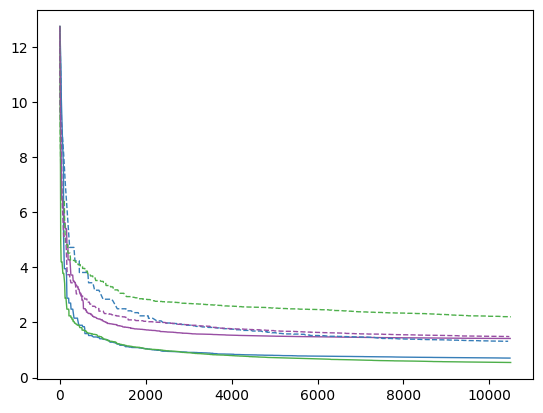

In [18]:
seed = 81

# plotting trajectories for one instance

for projection, rotation, psstype in itertools.product([0, 1], [1], [1, 2, 3]):
    thedf = df[
        (df["projection"] == projection)
        & (df["rotation"] == rotation)
        & (df["psstype"] == psstype)
        & (df["seed"] == seed)
    ]
    vx = thedf["rb_per_iteration_evaluations"].to_list()[0]
    vx = np.array(vx).cumsum()
    vf = thedf["rb_vf"].to_list()[0]
    vf = np.array(vf)
    # print(vf)
    print(vf[-1])

    plt.plot(
    vx,vf,
    color=cmap[projection][psstype - 1],
    linestyle=linestyles[projection],
    linewidth=linewidths[rotation],
    label=f"PSS{psstype} ({variants[projection]})",
    )

# plt.xlim(0,1000)